In [1]:
# obligatory imports
import sys
sys.path.append("../")

import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import joblib
import torch
import contextlib
import io
import random
import pickle
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

from dataset.data_classes import PytorchSpectraDataset
from dataset.dataset_builder import SpectralDatasetBuilder

from models.cdiff_lightning import LitCfgDiffusion
from models.cvae_lightning import LitVAE
from models.cbegan_lightning import SpectralCBEGAN

from utils.utils import encode_labels
from utils.experiments import generate_batch_spectra, load_models, load_colors

In [2]:
# Load data info, scalers and the categorical encoder
label_encoder = joblib.load("../pretrained_models/scalers/label_encoder.pkl")
minmax_scaler = joblib.load("../pretrained_models/scalers/minmax_scaler.pkl")
categorical_conditions = joblib.load("../pretrained_models/scalers/categorical_conditions.pkl")
continuous_conditions = joblib.load("../pretrained_models/scalers/continuous_conditions.pkl")
standard_scaler = joblib.load("../pretrained_models/scalers/std_scaler.pkl")

c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
# Load models
models = load_models()

In [4]:
dataset_builder = SpectralDatasetBuilder(data_path='../data/in-silico-gen-data.parquet', data_split={"train": 0.8, "test": 0.2}, config_path='../config.yaml')
dataset = PytorchSpectraDataset("../data/h4h_raw_2024-09-16_with_subject_ids.parquet")
column_names = dataset.df_test_scaled.iloc[:,:519].columns.values.astype(float)

In [5]:
df_real = dataset.create_single_visit_cohorts(dataset.df_test_scaled)
df_real = dataset.rebalance_single_visit_cohorts(df_real)
y_real = df_real[['age', 'sex', 'bmi']]

In [6]:
import numpy as np
import optuna

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted


class OptunaElasticNet(BaseEstimator, RegressorMixin):
    """
    ElasticNet with internal StandardScaler and Optuna hyperparameter tuning.

    This estimator:
    - Performs CV-based hyperparameter optimization
    - Avoids data leakage (scaling happens inside CV folds)
    - Refits on full dataset with best hyperparameters

    Parameters
    ----------
    cv : int, default=5
    scoring : str or callable, default='neg_mean_squared_error'
    random_state : int or None, default=None
    n_jobs : int or None, default=None
    alpha_range : tuple(float, float), default=(1e-4, 10.0)
    l1_ratio_range : tuple(float, float), default=(0.0, 1.0)
    max_iter : int, default=1000
    tol : float, default=1e-4
    """

    def __init__(
        self,
        cv=5,
        scoring="neg_mean_squared_error",
        random_state=None,
        n_jobs=None,
        alpha_range=(1e-4, 10.0),
        l1_ratio_range=(0.0, 1.0),
        max_iter=10000,
        tol=1e-4,
    ):
        self.cv = cv
        self.scoring = scoring
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.alpha_range = alpha_range
        self.l1_ratio_range = l1_ratio_range
        self.max_iter = max_iter
        self.tol = tol

    def _build_pipeline(self, alpha, l1_ratio):
        return Pipeline([
            ("scaler", StandardScaler()),
            ("elasticnet", ElasticNet(
                alpha=alpha,
                l1_ratio=l1_ratio,
                max_iter=self.max_iter,
                tol=self.tol,
                random_state=self.random_state,
            )),
        ])

    def fit(self, X, y, n_trials=10):
        X, y = check_X_y(X, y)

        cv_splitter = KFold(
            n_splits=self.cv,
            shuffle=True,
            random_state=self.random_state
        )

        def objective(trial):
            alpha = trial.suggest_float(
                "alpha",
                self.alpha_range[0],
                self.alpha_range[1],
                log=True
            )

            l1_ratio = trial.suggest_float(
                "l1_ratio",
                self.l1_ratio_range[0],
                self.l1_ratio_range[1]
            )

            model = self._build_pipeline(alpha, l1_ratio)

            scores = cross_val_score(
                model,
                X,
                y,
                cv=cv_splitter,
                scoring=self.scoring,
                n_jobs=self.n_jobs
            )

            return np.mean(scores)

        self.study_ = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=self.random_state)
        )

        self.study_.optimize(objective, n_trials=n_trials)

        self.best_params_ = self.study_.best_params

        # Final refit on full dataset
        self.model_ = self._build_pipeline(
            self.best_params_["alpha"],
            self.best_params_["l1_ratio"]
        )

        self.model_.fit(X, y)

        self.n_features_in_ = X.shape[1]

        return self

    def predict(self, X):
        check_is_fitted(self, "model_")
        X = check_array(X)
        return self.model_.predict(X)

    def score(self, X, y):
        check_is_fitted(self, "model_")
        return self.model_.score(X, y)

    @property
    def coef_(self):
        check_is_fitted(self, "model_")
        return self.model_.named_steps["elasticnet"].coef_

    @property
    def intercept_(self):
        check_is_fitted(self, "model_")
        return self.model_.named_steps["elasticnet"].intercept_

In [7]:
LABELS   = ['age', 'bmi']
TESTSETS = ['real', 'simulated']

colors = load_colors()

In [8]:
# ── Helper ────────────────────────────────────────────────────────────────────
 
def rescale(y, scaler, label):
    """Invert MinMaxScaler for the given label column (index 0=age, 1=bmi)."""
    col = 0 if label == 'age' else 1
    return (y - scaler.min_[col]) / scaler.scale_[col]

In [9]:
'''
# ── Run all combinations ──────────────────────────────────────────────────────
 
all_results = {}   # keyed by (label, teston)
 
for LABEL in LABELS:
    for TESTON in TESTSETS:
        print(f"\n{'='*60}")
        print(f"  LABEL={LABEL}  TESTON={TESTON}")
        print(f"{'='*60}")
 
        y_hats = {'real': []}
        for model_name in models:
            y_hats[model_name] = []
        y_tests = []
 
        for idx, X in df_real.groupby('test_set'):
            print(f'  Split: {idx}')
            split_ids = X.index.values
            y = y_real.loc[split_ids][LABEL].values
            X_arr = X.iloc[:, :519].values
 
            idx_train, idx_test = train_test_split(
                np.arange(len(y)), test_size=0.2, random_state=42
            )
            X_train, X_test   = X_arr[idx_train], X_arr[idx_test]
            y_train, y_test   = y[idx_train], y[idx_test]
            y_tests.append(y_test)
 
            # ── real data ──
            print('    evaluating real data')
            clf = OptunaElasticNet(max_iter=int(1e5), cv=5)
            clf.fit(X_train, y_train, n_trials=10)
            y_hats['real'].append(clf.predict(X_test))
 
            # ── simulated models ──
            for model_name, model in models.items():
                print(f'    evaluating {model_name}')
                X_sim = generate_batch_spectra(
                    model, y_real.loc[split_ids],
                    column_names=column_names, device="cpu"
                )
                X_train_sim = X_sim.values[idx_train]
                X_test_sim  = X_sim.values[idx_test]
 
                clf = OptunaElasticNet(max_iter=int(1e5), cv=5)
                clf.fit(X_train_sim, y_train, n_trials=10)
 
                if TESTON == 'real':
                    y_hat = clf.predict(X_test)
                else:  # simulated
                    y_hat = clf.predict(X_test_sim)
 
                y_hats[model_name].append(y_hat)
 
        # ── persist ──
        result = {'y_tests': y_tests, 'y_hats': y_hats}
        fname  = f'{LABEL}-{TESTON}-regression-results.pkl'
        with open(fname, 'wb') as f:
            pickle.dump(result, f)
        print(f'  Saved → {fname}')
 
        all_results[(LABEL, TESTON)] = result

''';

In [10]:
# ── (Optional) reload from disk instead of running above ─────────────────────
all_results = {}
for LABEL in LABELS:
    for TESTON in TESTSETS:
        fname = f'{LABEL}-{TESTON}-regression-results.pkl'
        with open(fname, 'rb') as f:
            all_results[(LABEL, TESTON)] = pickle.load(f)

In [11]:
# ── Metrics & resolution ──────────────────────────────────────────────────────
 
BIN_SIZE = 5
AGE_RANGE = (40, 80)
BMI_RANGE = (15, 45)
 
label_ranges = {'age': AGE_RANGE, 'bmi': BMI_RANGE}
 
def compute_metrics_and_resolution(y_tests, y_hats, label, scaler):
    model_names = list(y_hats.keys())
    lo, hi = label_ranges[label]
    bins    = np.arange(lo, hi + BIN_SIZE, BIN_SIZE)
    bin_max = bins[1:]
 
    mean_r  = {}; std_r  = {}
    mean_mse= {}; std_mse= {}
    total_res    = {}
    binned_res   = {}
 
    for mn in model_names:
        rs, mses = [], []
        for i in range(len(y_tests)):
            yt = rescale(y_tests[i],        scaler, label)
            yh = rescale(y_hats[mn][i],     scaler, label)
            rs.append(np.corrcoef(yt, yh)[0, 1])
            mses.append(mean_squared_error(yt, yh))
 
        mean_r[mn]   = np.mean(rs);   std_r[mn]   = np.std(rs)
        mean_mse[mn] = np.mean(mses); std_mse[mn] = np.std(mses)
 
        # overall resolution – on rescaled values
        yt_all = rescale(np.hstack(y_tests),      scaler, label)
        yh_all = rescale(np.hstack(y_hats[mn]),   scaler, label)
        total_res[mn] = np.std(yh_all - yt_all)
 
        # binned resolution
        residuals  = yh_all - yt_all
        resolutions = []
        for j in range(len(bins) - 1):
            mask = (yt_all >= bins[j]) & (yt_all < bins[j + 1])
            resolutions.append(np.std(residuals[mask]) if mask.sum() > 1 else np.nan)
        binned_res[mn] = np.array(resolutions)
 
    return mean_r, std_r, mean_mse, std_mse, total_res, binned_res, bin_max

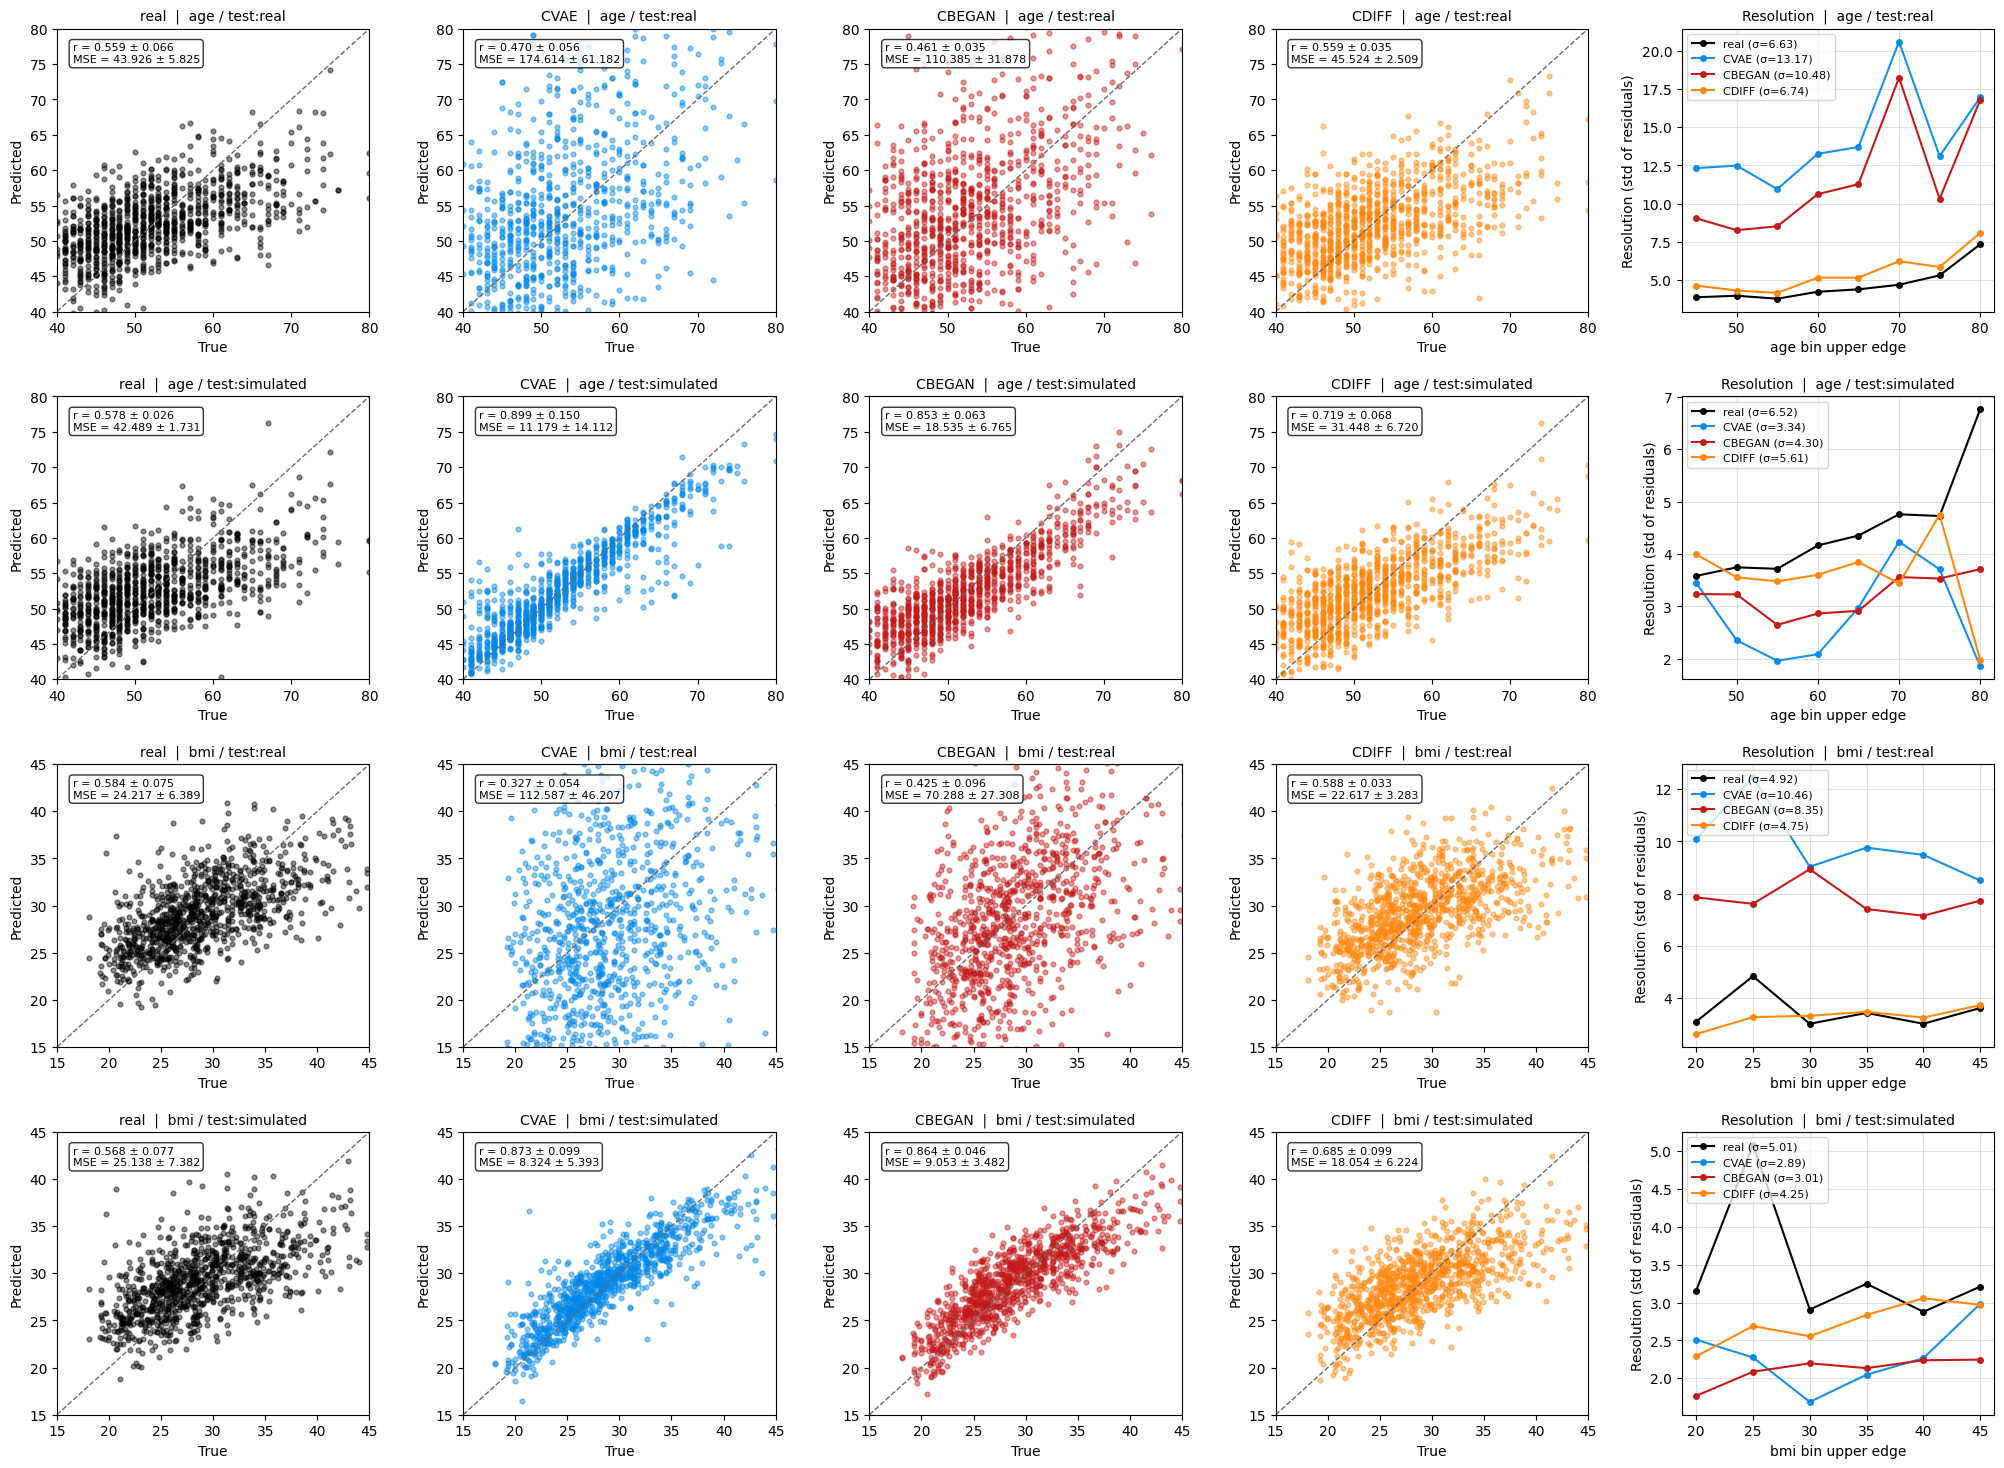

In [11]:
# ── Figure layout ─────────────────────────────────────────────────────────────
#
#  Rows:    one per (LABEL × TESTON) combination  →  4 rows
#  Columns: one scatter per model (real, CVAE, CBEGAN, CDIFF) + 1 resolution
#           = 5 columns
#
# ─────────────────────────────────────────────────────────────────────────────
 
combo_list  = [(la, te) for la in LABELS for te in TESTSETS]   # 4 rows
model_order = ['real', 'CVAE', 'CBEGAN', 'CDIFF']
n_rows      = len(combo_list)
n_scatter   = len(model_order)
n_cols      = n_scatter + 1   # +1 for resolution panel
 
fig = plt.figure(figsize=(5 * n_cols, 4.5 * n_rows))
outer_gs = gridspec.GridSpec(n_rows, n_cols, figure=fig,
                              hspace=0.3, wspace=0.3)
 
for row_idx, (LABEL, TESTON) in enumerate(combo_list):
    result  = all_results[(LABEL, TESTON)]
    y_tests = result['y_tests']
    y_hats  = result['y_hats']
 
    lo, hi = label_ranges[LABEL]
    lim    = (lo, hi)
    ref    = np.linspace(lo, hi, 100)
 
    (mean_r, std_r, mean_mse, std_mse,
     total_res, binned_res, bin_max) = compute_metrics_and_resolution(
        y_tests, y_hats, LABEL, minmax_scaler
    )
 
    # ── scatter panels ──
    for col_idx, mn in enumerate(model_order):
        ax = fig.add_subplot(outer_gs[row_idx, col_idx])
 
        yt = rescale(np.hstack(y_tests),      minmax_scaler, LABEL)
        yh = rescale(np.hstack(y_hats[mn]),   minmax_scaler, LABEL)
 
        ax.scatter(yt, yh, color=colors[mn], alpha=0.45, s=12)
        ax.plot(ref, ref, linestyle='dashed', color='dimgrey', linewidth=1)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel('True', fontsize=10)
        ax.set_ylabel('Predicted', fontsize=10)
        ax.set_title(f'{mn}  |  {LABEL} / test:{TESTON}', fontsize=10)
        ax.text(
            0.05, 0.95,
            f"r = {mean_r[mn]:.3f} ± {std_r[mn]:.3f}\n"
            f"MSE = {mean_mse[mn]:.3f} ± {std_mse[mn]:.3f}",
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )
 
    # ── resolution panel ──
    ax_res = fig.add_subplot(outer_gs[row_idx, n_scatter])
    for mn in model_order:
        ax_res.plot(
            bin_max, binned_res[mn],
            marker='o', markersize=4, linewidth=1.5,
            label=f'{mn} (σ={total_res[mn]:.2f})',
            color=colors[mn]
        )
    ax_res.set_xlabel(f'{LABEL} bin upper edge', fontsize=10)
    ax_res.set_ylabel('Resolution (std of residuals)', fontsize=10)
    ax_res.set_title(f'Resolution  |  {LABEL} / test:{TESTON}',
                     fontsize=10)
    ax_res.legend(fontsize=8, loc='upper left')
    ax_res.grid(True, alpha=0.4)

 
plt.savefig('regression_all_combinations.png', bbox_inches='tight', dpi=300)
plt.show()

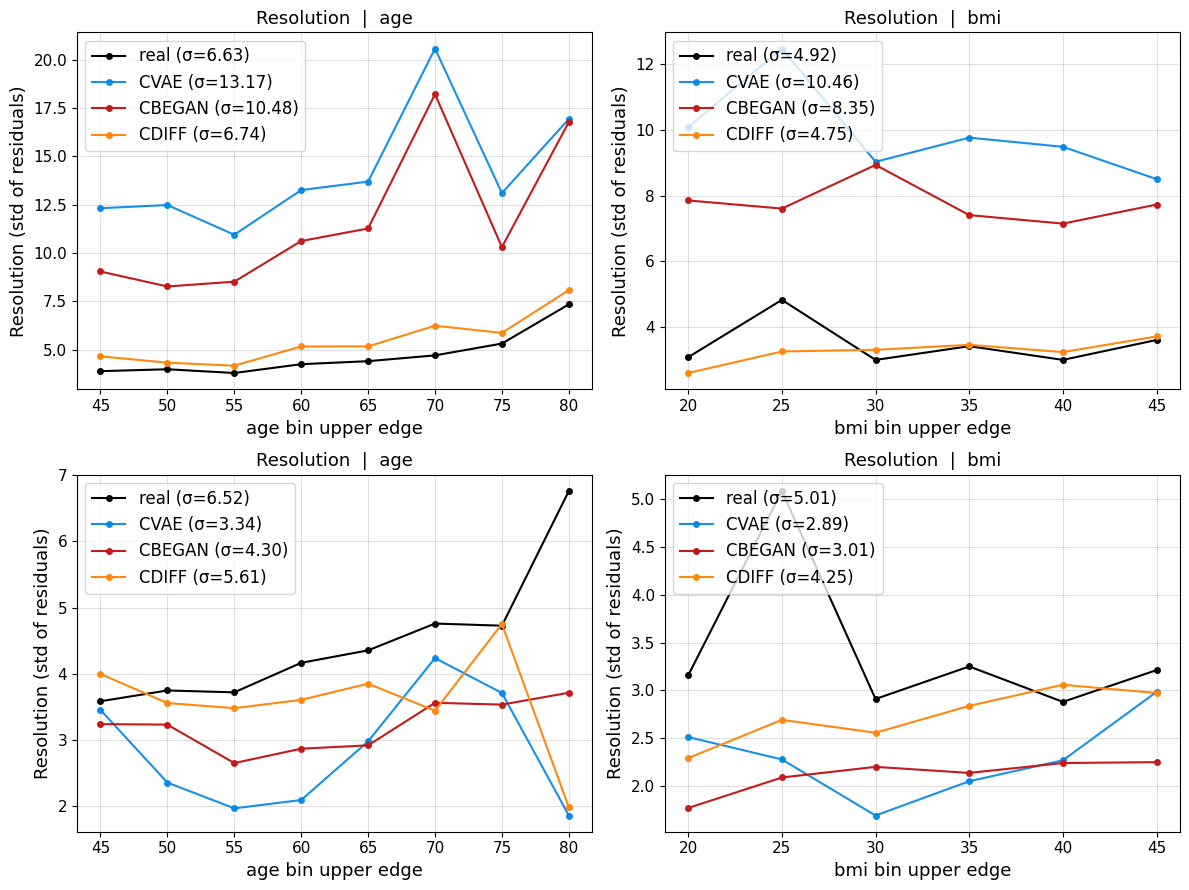

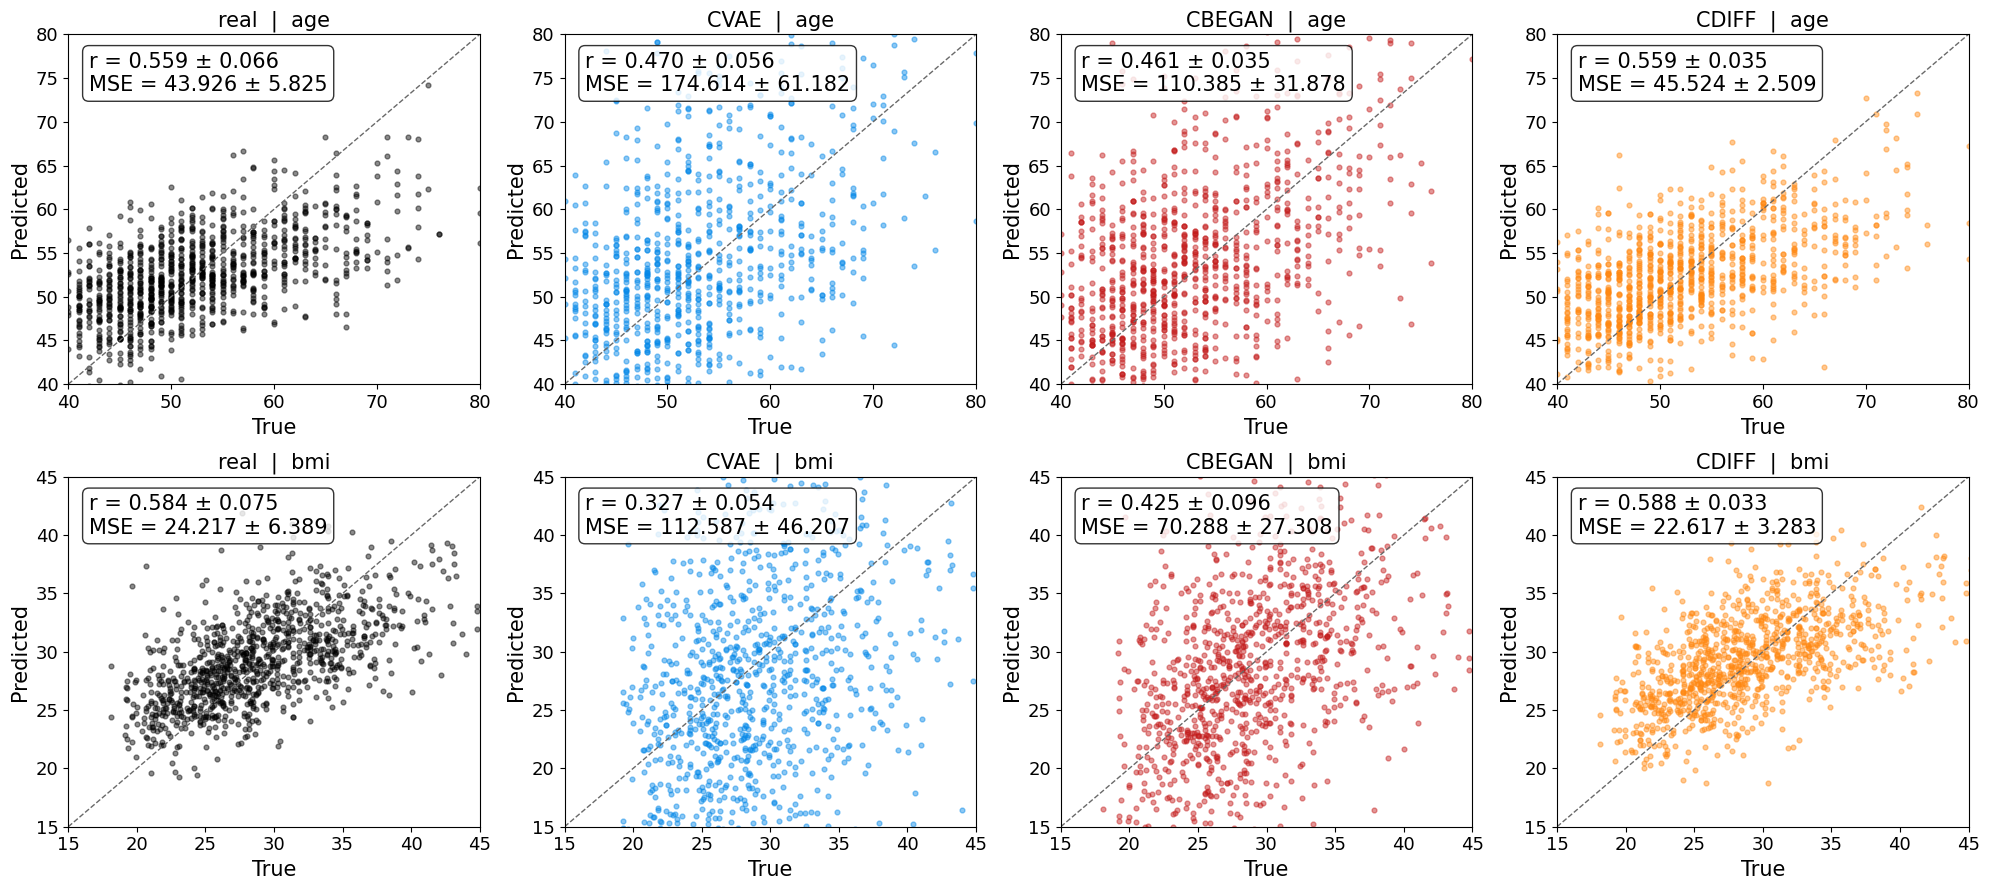

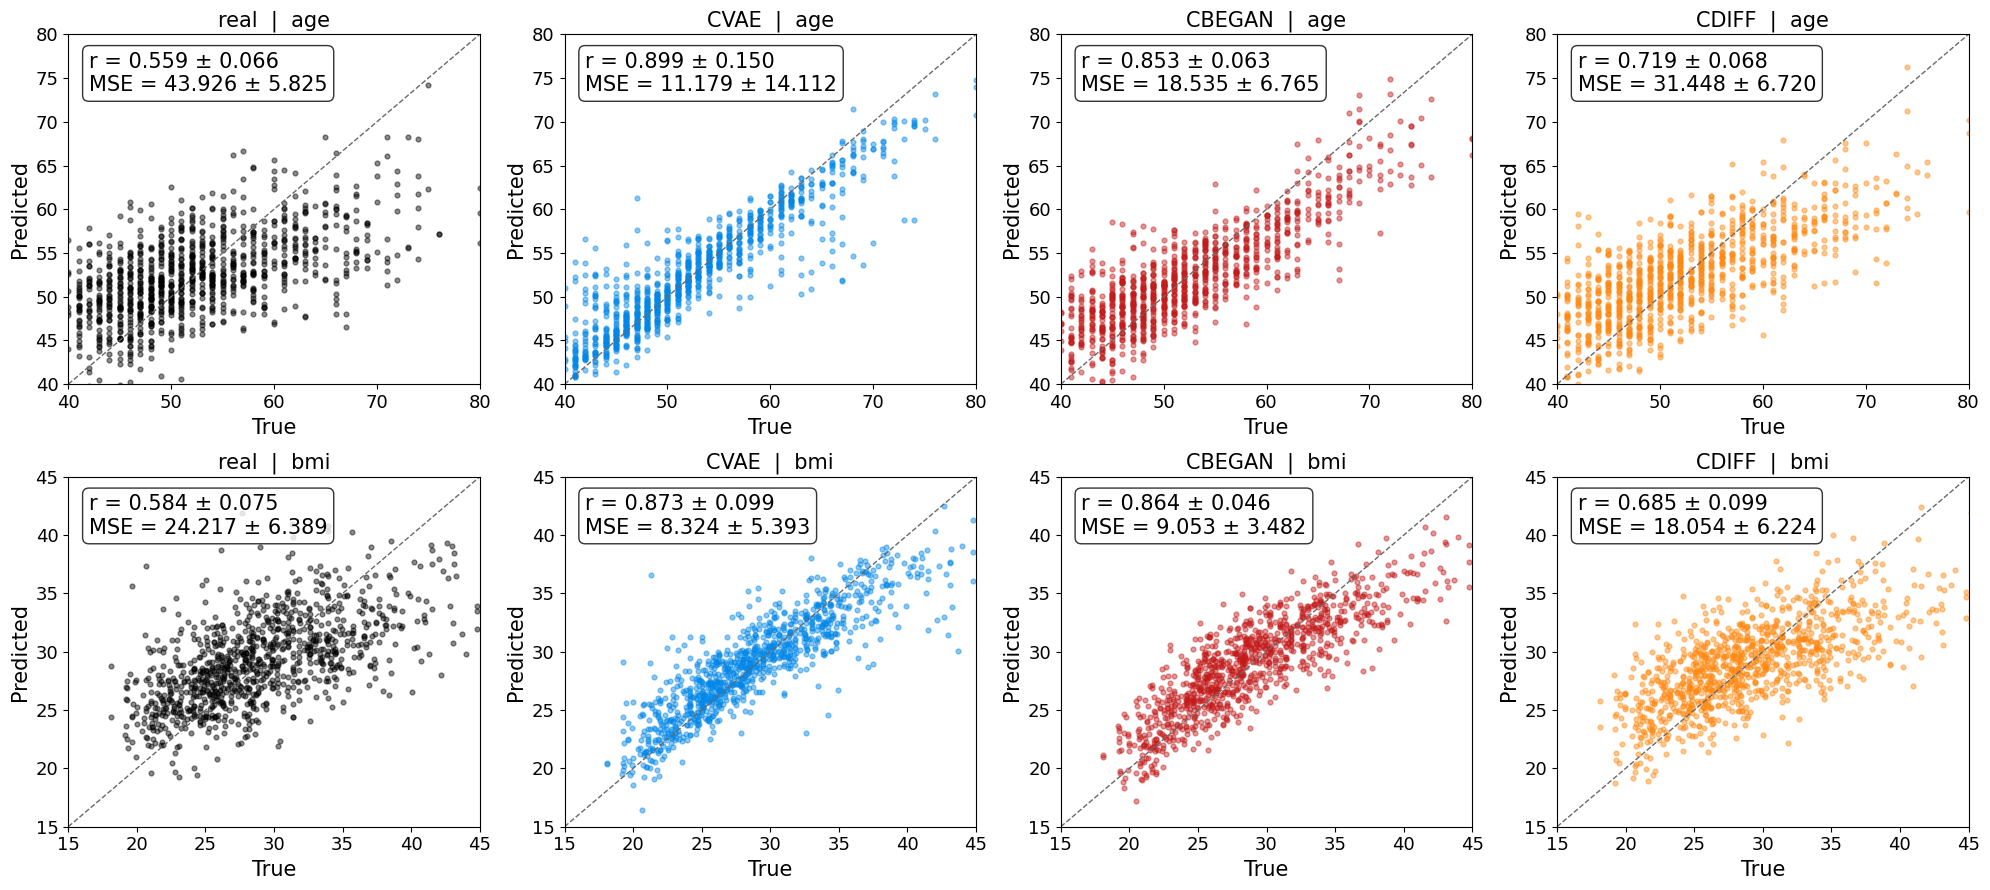

In [15]:
# ── Figure layout (split into 3 figures) ─────────────────────────────────────
#
#  Figure 1: Resolution plots only (2 rows × 1 col: age, bmi)
#  Figure 2: Scatter plots – always testing on REAL data (2 rows × 4 cols)
#  Figure 3: Scatter plots – train & test on SAME data type (2 rows × 4 cols)
#
# ─────────────────────────────────────────────────────────────────────────────

model_order = ['real', 'CVAE', 'CBEGAN', 'CDIFF']

# ── Pre-compute metrics for all combinations ──────────────────────────────────
metrics = {}
for LABEL in LABELS:
    for TESTON in TESTSETS:
        result  = all_results[(LABEL, TESTON)]
        metrics[(LABEL, TESTON)] = compute_metrics_and_resolution(
            result['y_tests'], result['y_hats'], LABEL, minmax_scaler
        )

# ─────────────────────────────────────────────────────────────────────────────
# Figure 1 – Resolution (2 rows × 2 cols: label × teston)
# ─────────────────────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(len(LABELS), len(TESTSETS),
                            figsize=(12, 4.5 * len(LABELS)))

for row_idx, TESTON in enumerate(TESTSETS):
    for col_idx, LABEL in enumerate(LABELS):
        ax_res = axes1[row_idx, col_idx]

        (mean_r, std_r, mean_mse, std_mse,
         total_res, binned_res, bin_max) = metrics[(LABEL, TESTON)]

        for mn in model_order:
            ax_res.plot(
                bin_max, binned_res[mn],
                marker='o', markersize=4, linewidth=1.5,
                label=f'{mn} (σ={total_res[mn]:.2f})',
                color=colors[mn]
            )
        ax_res.set_xlabel(f'{LABEL} bin upper edge', fontsize=13)
        ax_res.set_ylabel('Resolution (std of residuals)', fontsize=13)
        ax_res.tick_params(axis='both', labelsize=11)
        ax_res.set_title(f'Resolution  |  {LABEL}', fontsize=13)
        ax_res.legend(fontsize=12, loc='upper left')
        ax_res.grid(True, alpha=0.4)

fig1.tight_layout()
plt.savefig('fig1_resolution.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figure 2 – Scatter: always test on REAL data
# ─────────────────────────────────────────────────────────────────────────────
TESTON = 'real'
n_scatter = len(model_order)

fig2, axes2 = plt.subplots(len(LABELS), n_scatter,
                            figsize=(5 * n_scatter, 4.5 * len(LABELS)))

for row_idx, LABEL in enumerate(LABELS):
    result  = all_results[(LABEL, TESTON)]
    y_tests = result['y_tests']
    y_hats  = result['y_hats']
    lo, hi  = label_ranges[LABEL]
    lim     = (lo, hi)
    ref     = np.linspace(lo, hi, 100)

    (mean_r, std_r, mean_mse, std_mse,
     total_res, binned_res, bin_max) = metrics[(LABEL, TESTON)]

    for col_idx, mn in enumerate(model_order):
        ax = axes2[row_idx, col_idx]

        yt = rescale(np.hstack(y_tests),      minmax_scaler, LABEL)
        yh = rescale(np.hstack(y_hats[mn]),   minmax_scaler, LABEL)

        ax.scatter(yt, yh, color=colors[mn], alpha=0.45, s=12)
        ax.plot(ref, ref, linestyle='dashed', color='dimgrey', linewidth=1)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel('True', fontsize=15)
        ax.set_ylabel('Predicted', fontsize=15)
        ax.tick_params(axis='both', labelsize=13)
        ax.set_title(f'{mn}  |  {LABEL}', fontsize=15)
        ax.text(
            0.05, 0.95,
            f"r = {mean_r[mn]:.3f} ± {std_r[mn]:.3f}\n"
            f"MSE = {mean_mse[mn]:.3f} ± {std_mse[mn]:.3f}",
            transform=ax.transAxes, va='top', fontsize=15,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

fig2.tight_layout()
plt.savefig('fig2_scatter_test_real.png', bbox_inches='tight', dpi=300)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figure 3 – Scatter: train & test on SAME data type
#   • 'real' subplot: from (LABEL, 'real') results, using mn='real'
#   • model subplots: from (LABEL, 'simulated') results, using respective mn
# ─────────────────────────────────────────────────────────────────────────────

fig3, axes3 = plt.subplots(len(LABELS), n_scatter,
                            figsize=(5 * n_scatter, 4.5 * len(LABELS)))

for row_idx, LABEL in enumerate(LABELS):
    lo, hi = label_ranges[LABEL]
    lim    = (lo, hi)
    ref    = np.linspace(lo, hi, 100)

    for col_idx, mn in enumerate(model_order):
        ax = axes3[row_idx, col_idx]

        # Real subplot: train=real, test=real  →  use TESTON='real', mn='real'
        # Model subplots: train=sim, test=sim  →  use TESTON='simulated', mn=mn
        if mn == 'real':
            result_key = (LABEL, 'real')
        else:
            result_key = (LABEL, 'simulated')

        result  = all_results[result_key]
        y_tests = result['y_tests']
        y_hats  = result['y_hats']

        (mean_r, std_r, mean_mse, std_mse,
         total_res, binned_res, bin_max) = metrics[result_key]

        yt = rescale(np.hstack(y_tests),      minmax_scaler, LABEL)
        yh = rescale(np.hstack(y_hats[mn]),   minmax_scaler, LABEL)

        ax.scatter(yt, yh, color=colors[mn], alpha=0.45, s=12)
        ax.plot(ref, ref, linestyle='dashed', color='dimgrey', linewidth=1)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel('True', fontsize=15)
        ax.set_ylabel('Predicted', fontsize=15)
        ax.tick_params(axis='both', labelsize=13)
        ax.set_title(f'{mn}  |  {LABEL}', fontsize=15)
        ax.text(
            0.05, 0.95,
            f"r = {mean_r[mn]:.3f} ± {std_r[mn]:.3f}\n"
            f"MSE = {mean_mse[mn]:.3f} ± {std_mse[mn]:.3f}",
            transform=ax.transAxes, va='top', fontsize=15,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

fig3.tight_layout()
plt.savefig('fig3_scatter_same_domain.png', bbox_inches='tight', dpi=300)
plt.show()
